# Part 2 : Preprocessing Data + STL Decomposition

This notebook aims to:
1. Normalize the time series.
2. Decompose it into trend, seasonal, and residual components using STL.
3. Analyze which component is most informative for anomaly detection.

In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
sns.set_style("whitegrid")

In [7]:
df = pd.read_csv("C:/Users/owen/projects/time-series-anomaly-detection/data/raw/A1Benchmark/real_1.csv")
df.head()

,timestamp,value,is_anomaly
0,1,0.000000,0
1,2,0.091758,0
2,3,0.172297,0
3,4,0.226219,0
4,5,0.176358,0


In [8]:
##Fill missing values
df['value'] = df['value'].ffill()
##Scaling
scaler= StandardScaler()
df['value_scaled'] = scaler.fit_transform(df['value'].values.reshape(-1,1))

# Create the directory if it doesn't exist
import os
os.makedirs('data/raw/A1Benchmark', exist_ok=True)
df.to_csv('data/raw/A1Benchmark/real_1_scaled.csv', index=False)

**Scaling ensures numerical stability.**

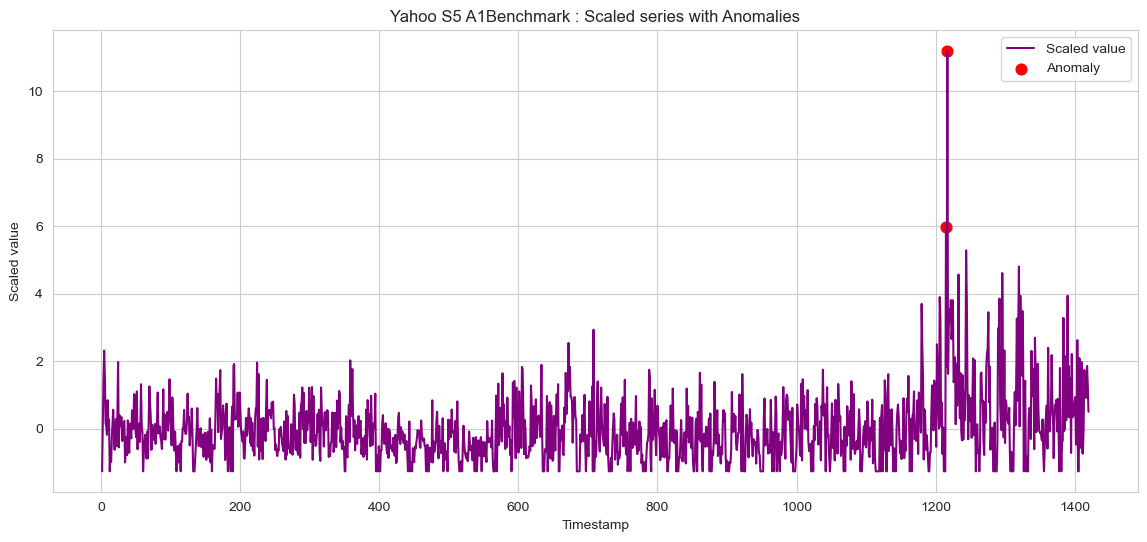

In [9]:
plt.figure(figsize=(14,6))
plt.plot(df['timestamp'], df['value_scaled'], label='Scaled value', color='purple')
plt.scatter(df['timestamp'][df['is_anomaly']==1], df['value_scaled'][df['is_anomaly']==1],color='red',
            label='Anomaly', s=60)
plt.xlabel('Timestamp')
plt.ylabel('Scaled value')
plt.title('Yahoo S5 A1Benchmark : Scaled series with Anomalies')
plt.legend()
plt.show()

## STL Decomposition

STL decomposes the time series data into:
- **Trend**: Long-term movement
- **Seasonality**: Repeating patterns
- **Residual**: Irregular component

Anomalies are expected to be most visible in the residual.

In [14]:
stl = STL(df["value_scaled"],period=24)
result = stl.fit()
df["trend"] = result.trend
df["seasonal"] = result.seasonal
df["residual"] = result.resid

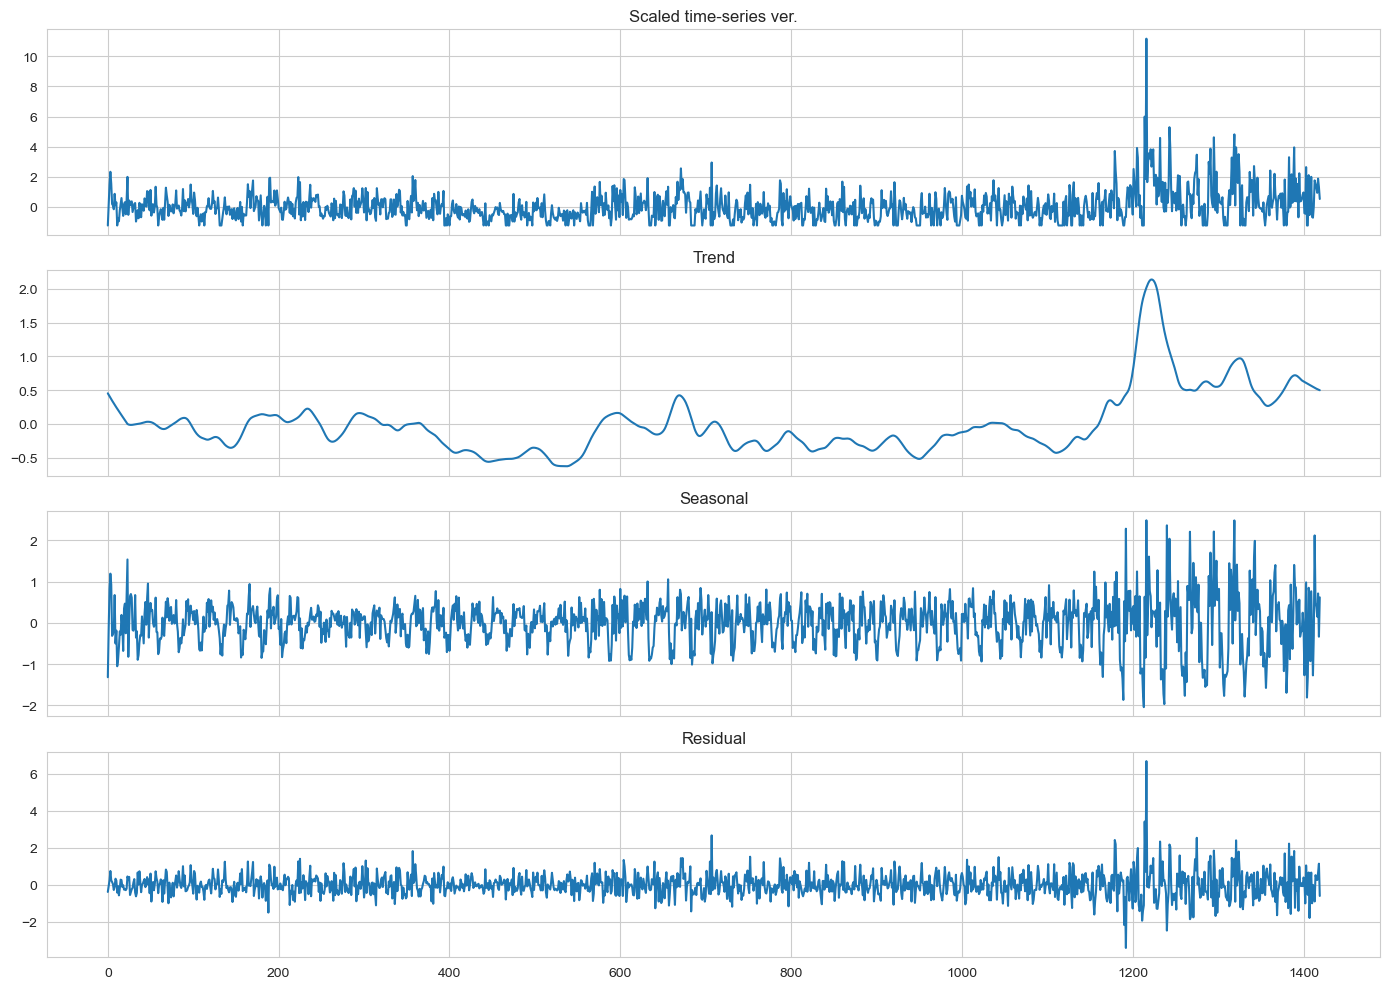

In [17]:
fig,axes = plt.subplots(4,1,figsize=(14,10),sharex=True)
axes[0].plot(df["value_scaled"])
axes[0].set_title("Scaled time-series ver.")
axes[1].plot(df["trend"])
axes[1].set_title("Trend")
axes[2].plot(df["seasonal"])
axes[2].set_title("Seasonal")
axes[3].plot(df["residual"])
axes[3].set_title("Residual")
plt.tight_layout()
plt.show()

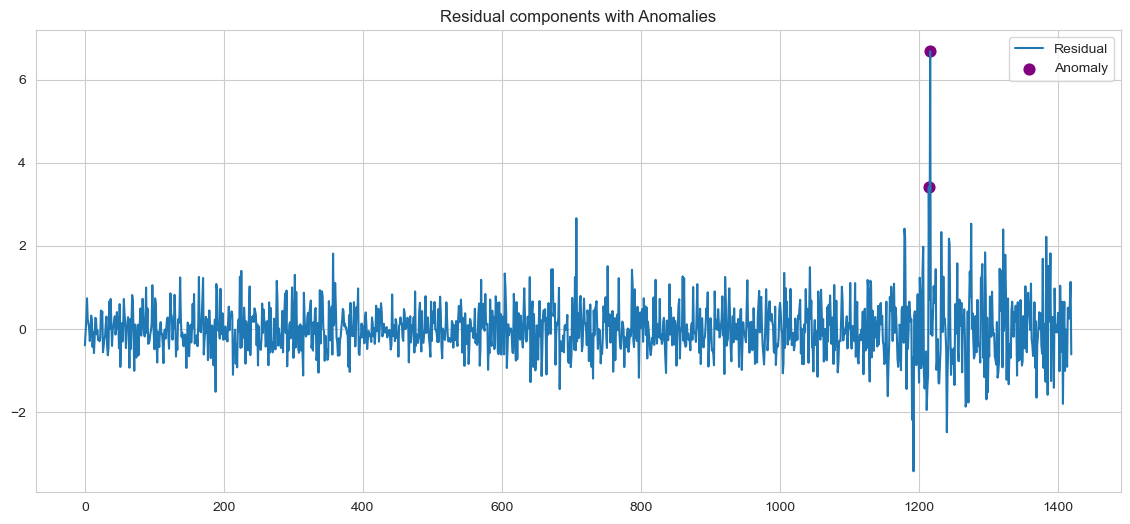

In [18]:
plt.figure(figsize=(14,6))
plt.plot(df["residual"], label="Residual")
plt.scatter(df.index[df["is_anomaly"]==1], df["residual"][df["is_anomaly"]==1],
            color="purple", label="Anomaly", s=60)
plt.legend()
plt.title("Residual components with Anomalies")
plt.show()

## Observations : 

- Trend captures long-term behavior unrelated to anomalies
- Seasonal captures regular cycles
- Residual amplifies the anomalous behavior
- Many labeled anomalies correspond to large residual values

Applying anomaly detection on the residual may improve detection performance.

In [20]:
df.to_csv("data/raw/A1Benchmark/real_1_processed.csv",index=False)